In [2]:
from Meta_learning import MetaLearner
import Meta_loss_functions as mlf
from CNN_experiments import Generator4x4, CNN4x4

1. Cross-entropy without regularization:

step: 29, meta_loss: 0.0237, accuracy: 100.00%


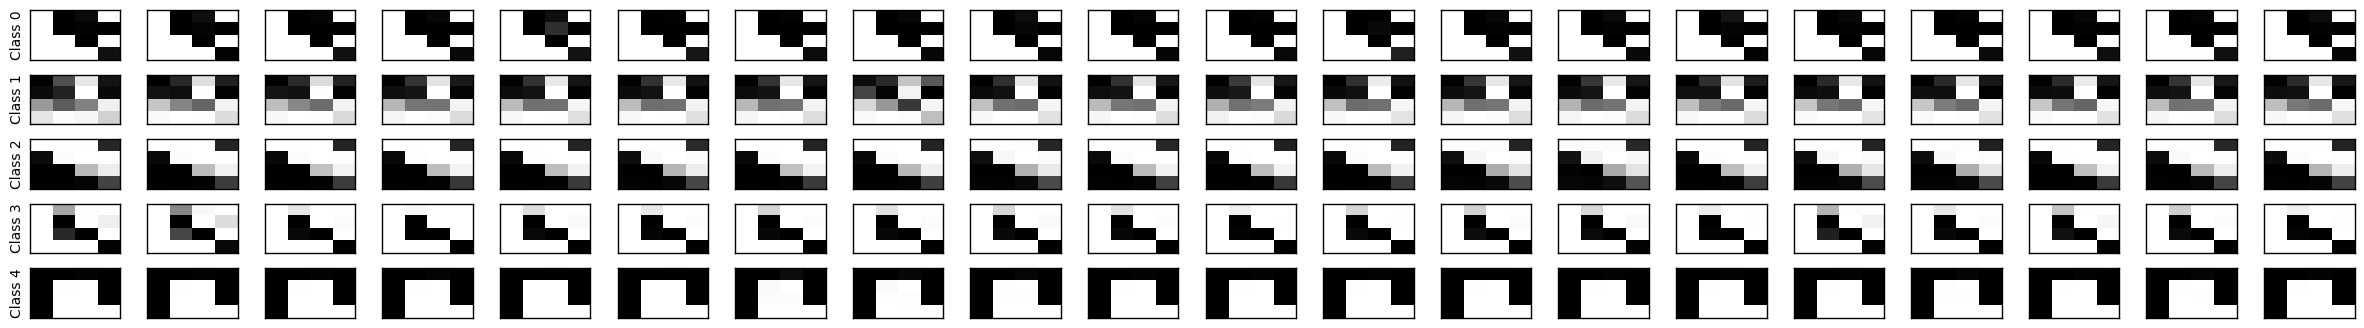

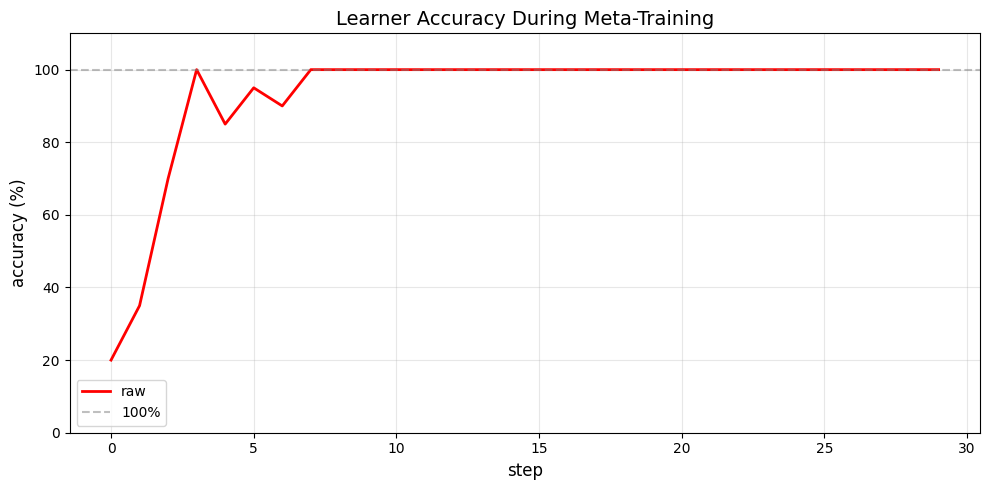

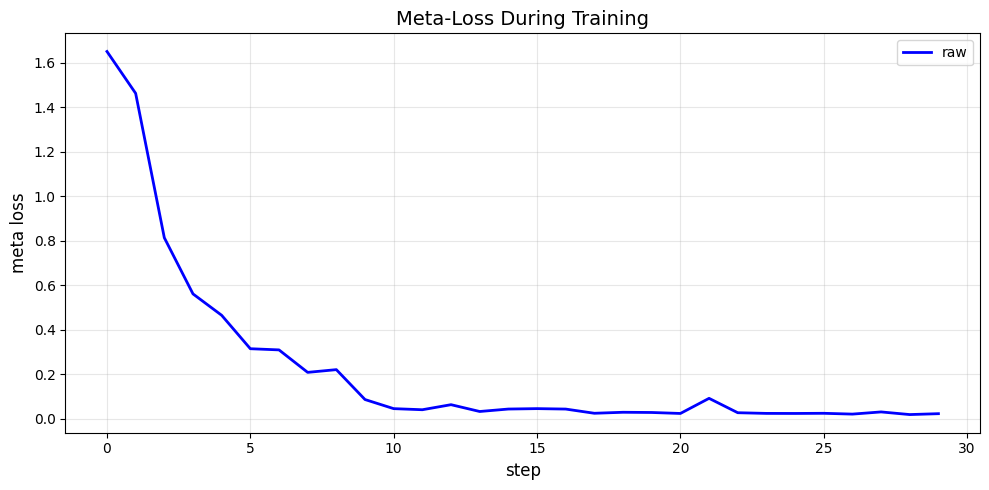

In [3]:
generator = Generator4x4(latent_dim=32, num_classes=5)

meta = MetaLearner(
    generator=generator,
    learner_class=CNN4x4,
    meta_loss_fn=mlf.meta_loss_cross_entropy,
    num_classes=5,
    n_per_class=20,
    latent_dim=32,
    meta_lr=0.01,
    inner_lr=0.1,
    inner_steps=100,
)

meta.train(steps=30, visualize_every=0)
meta.plot_accuracy(1)
meta.plot_meta_loss(1)
acc_ce_without_reg = meta.get_accuracy_history()

2. MSE without regularization:

step: 29, meta_loss: 0.0004, accuracy: 100.00%


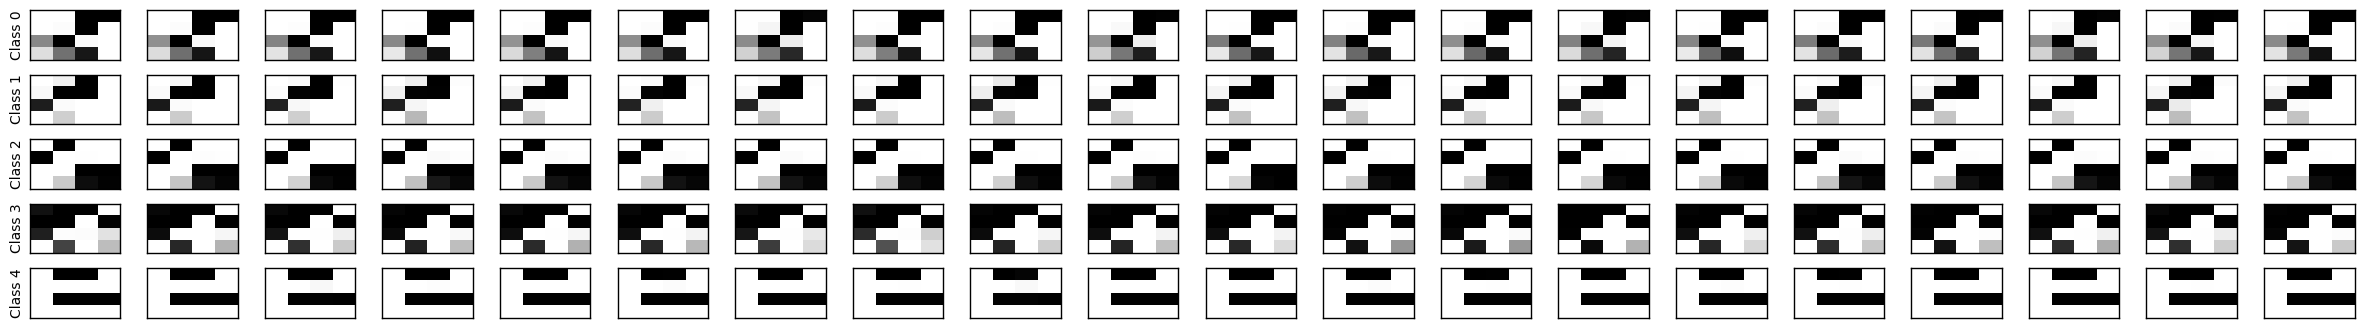

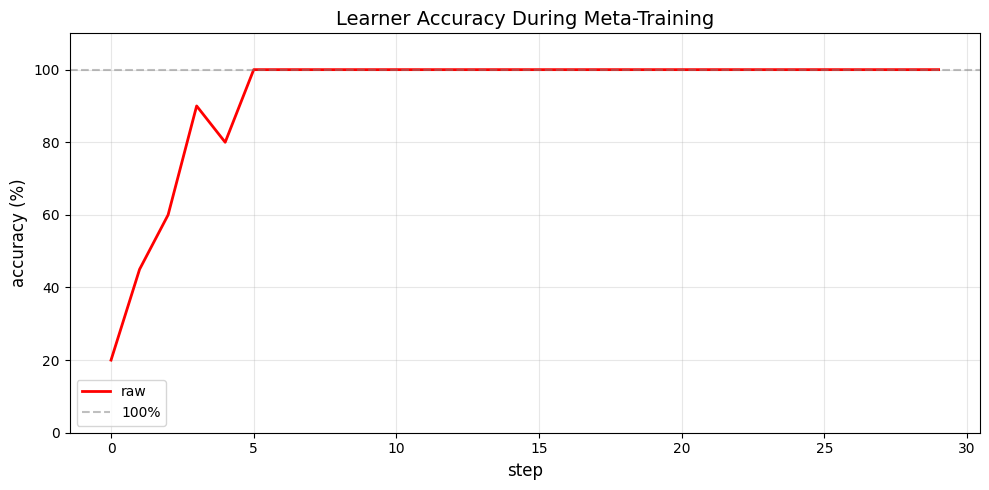

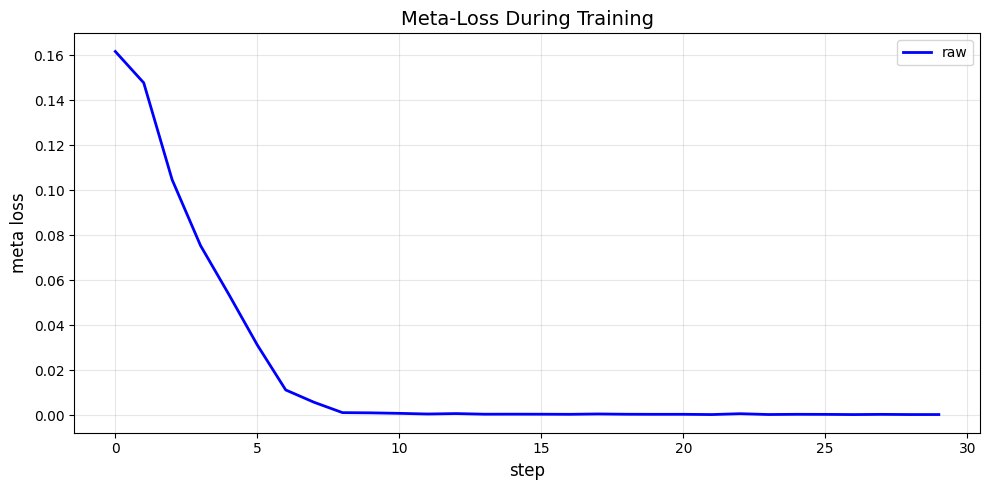

In [4]:
generator = Generator4x4(latent_dim=32, num_classes=5)

meta = MetaLearner(
    generator=generator,
    learner_class=CNN4x4,
    meta_loss_fn=mlf.meta_loss_mse,
    num_classes=5,
    n_per_class=20,
    latent_dim=32,
    meta_lr=0.01,
    inner_lr=0.1,
    inner_steps=100,
)

meta.train(steps=30, visualize_every=0)
meta.plot_accuracy(1)
meta.plot_meta_loss(1)
acc_mse_without_reg = meta.get_accuracy_history()

As can be seen, both variants quickly lead to the trivial case where all images within a given class are identical.

3. Cross-entropy with class diversity regularization:

step: 99, meta_loss: -0.3073, accuracy: 100.00%


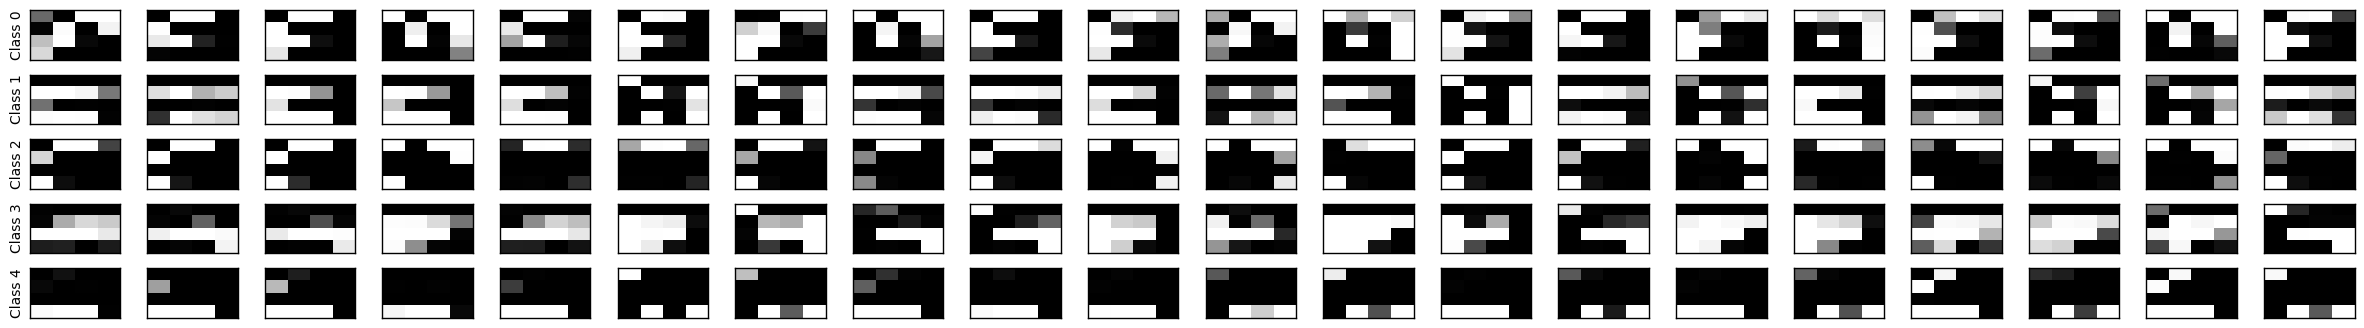

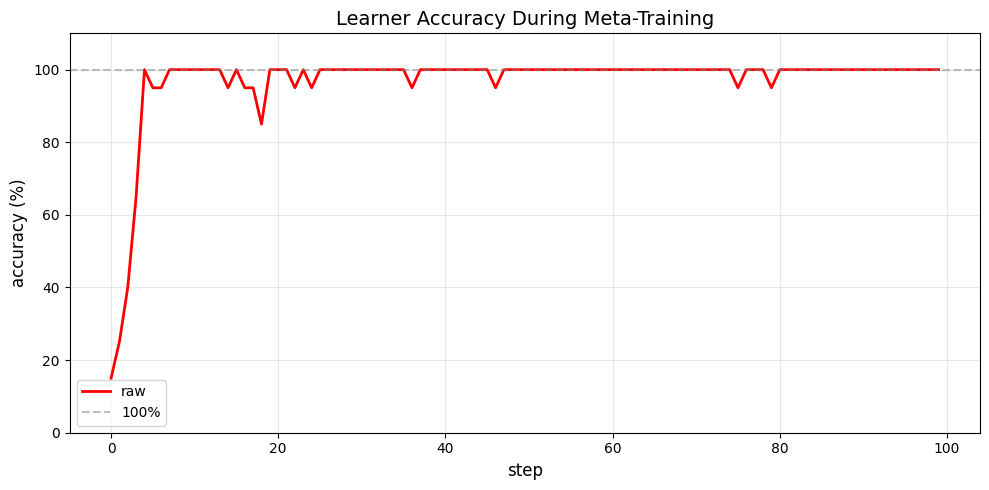

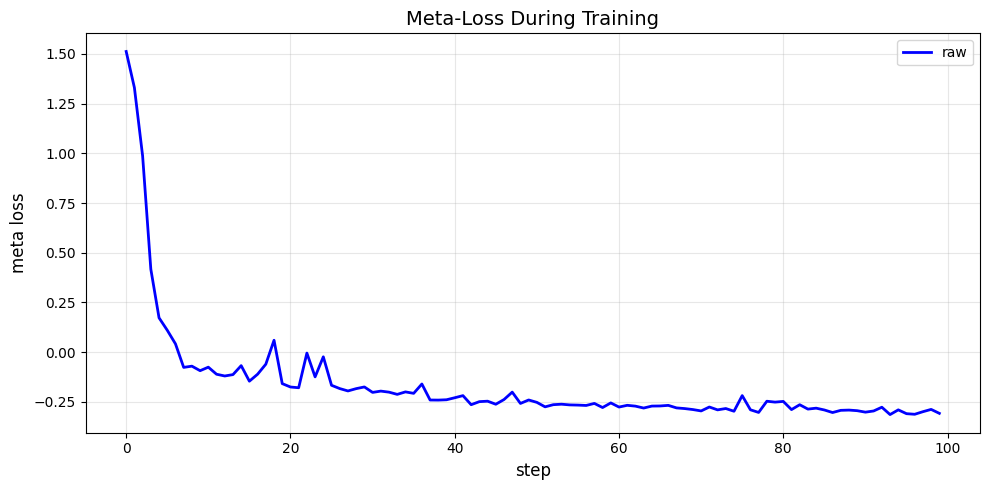

In [14]:
generator = Generator4x4(latent_dim=32, num_classes=5)

meta = MetaLearner(
    generator=generator,
    learner_class=CNN4x4,
    meta_loss_fn=mlf.meta_loss_cross_entropy,
    num_classes=5,
    n_per_class=20,
    latent_dim=32,
    regularization_fn=mlf.regularizer_class_diversity,
    reg_parameter=1,
    meta_lr=0.01,
    inner_lr=0.1,
    inner_steps=100,
)

meta.train(steps=100, visualize_every=0)
meta.plot_accuracy(1)
meta.plot_meta_loss(1)
acc_ce_diversity_reg = meta.get_accuracy_history()

4. MSE with class diversity regularization:

step: 99, meta_loss: -0.0217, accuracy: 100.00%


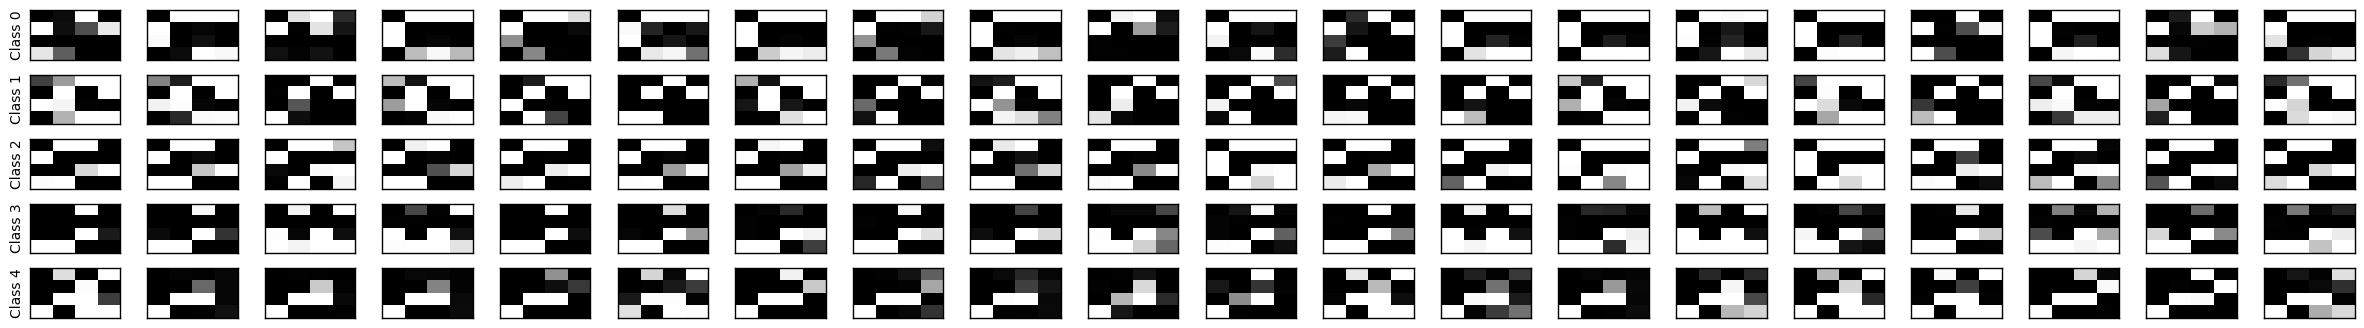

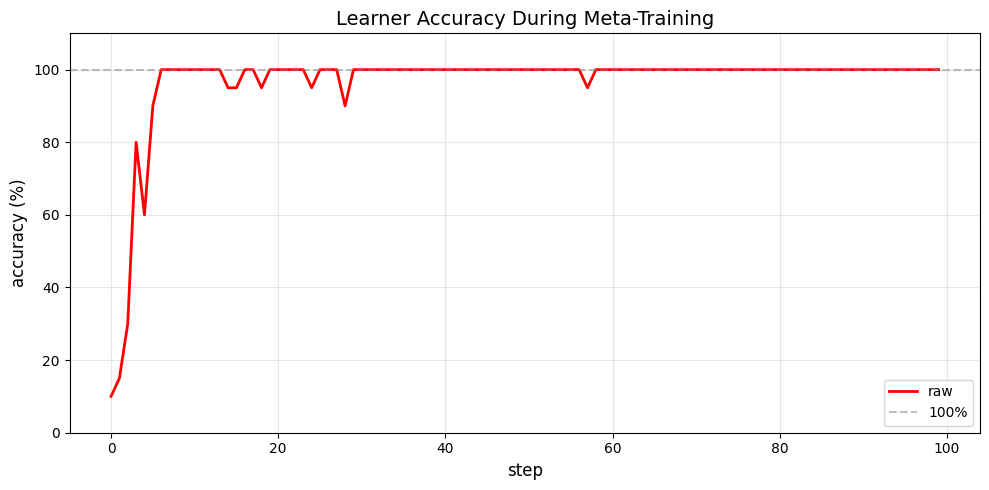

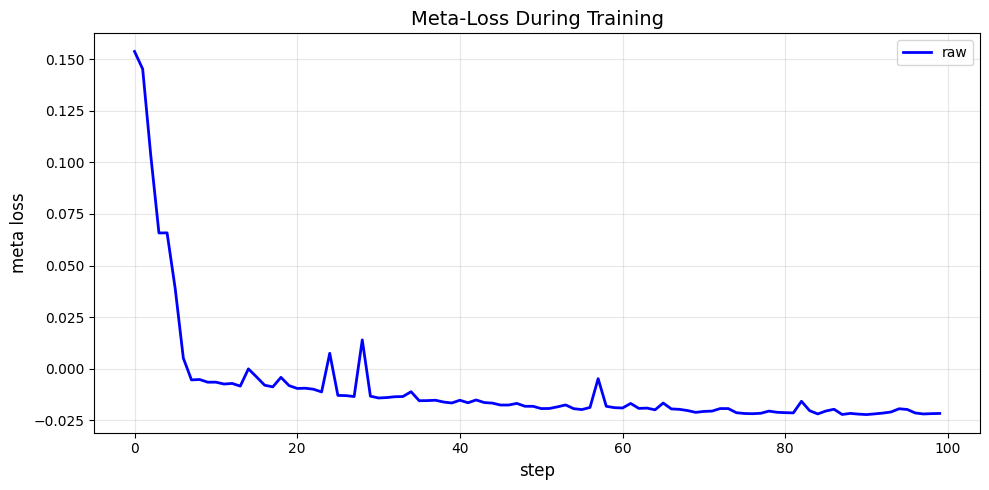

In [10]:
generator = Generator4x4(latent_dim=32, num_classes=5)

meta = MetaLearner(
    generator=generator,
    learner_class=CNN4x4,
    meta_loss_fn=mlf.meta_loss_mse,
    num_classes=5,
    n_per_class=20,
    latent_dim=32,
    regularization_fn=mlf.regularizer_class_diversity,
    reg_parameter=0.08,
    meta_lr=0.01,
    inner_lr=0.1,
    inner_steps=100,
)

meta.train(steps=100, visualize_every=0)
meta.plot_accuracy(1)
meta.plot_meta_loss(1)
acc_mse_diversity_reg = meta.get_accuracy_history()

5. Cross-entropy with svd regularization:

step: 99, meta_loss: 0.0395, accuracy: 100.00%


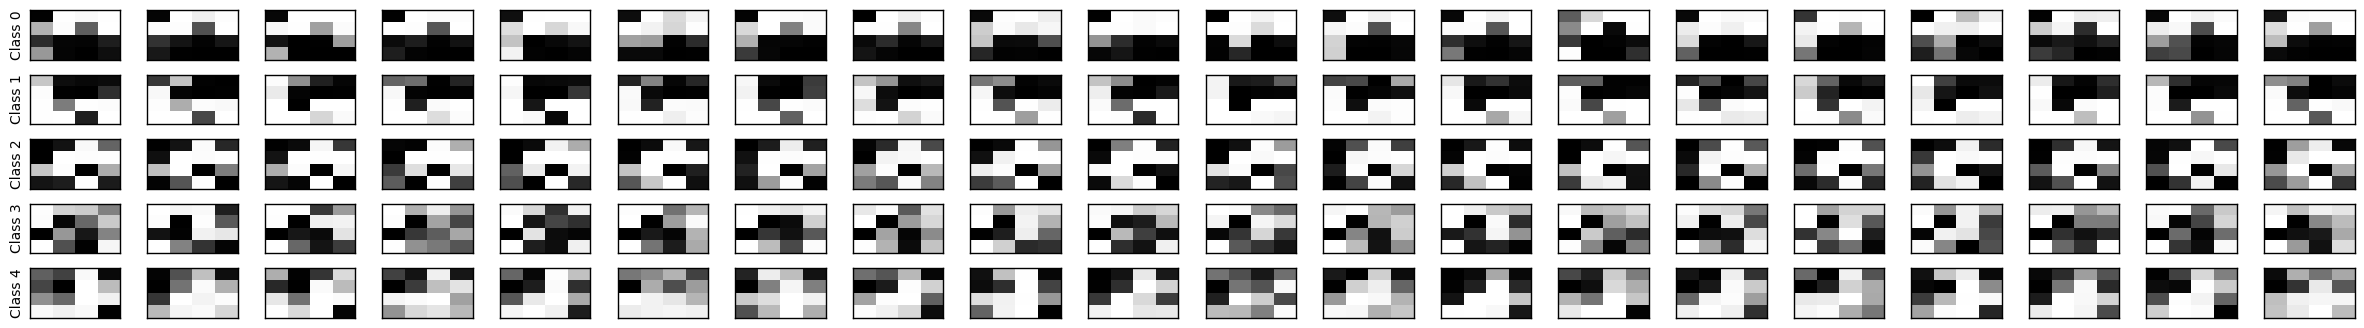

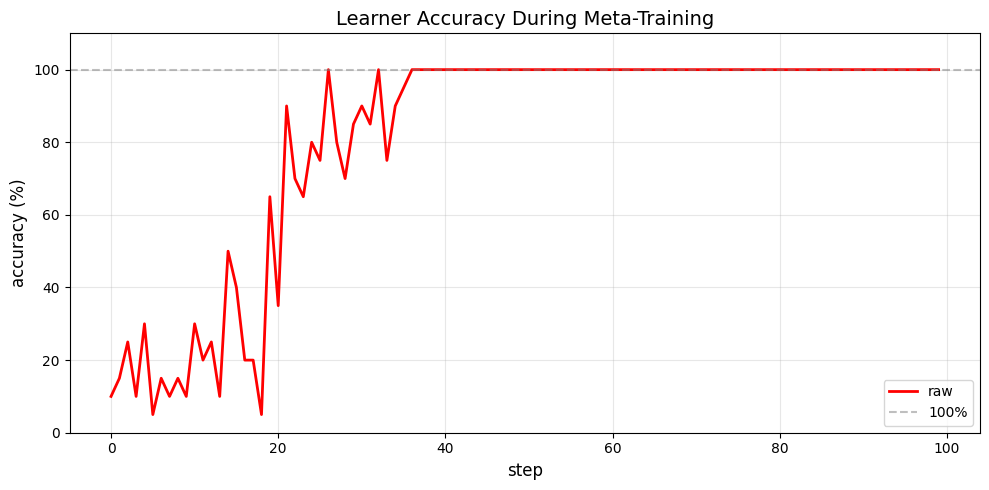

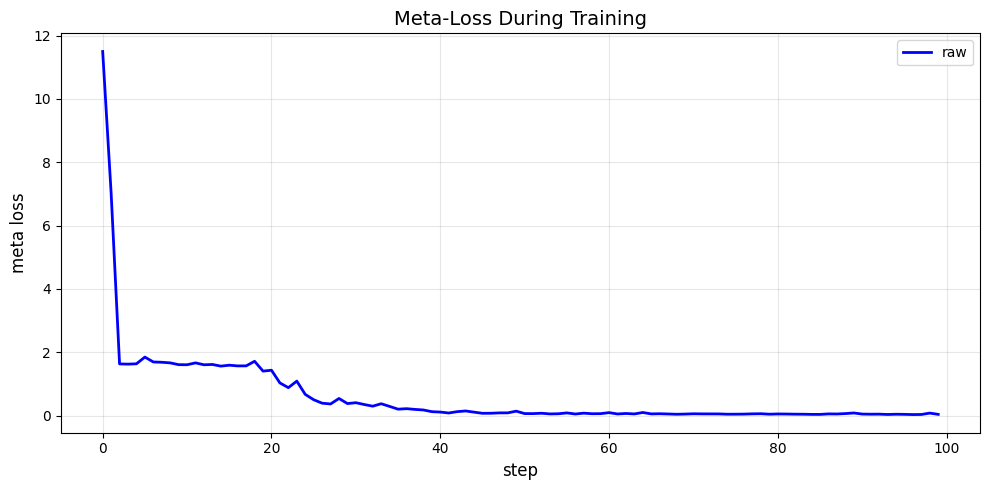

In [13]:
generator = Generator4x4(latent_dim=32, num_classes=5)

meta = MetaLearner(
    generator=generator,
    learner_class=CNN4x4,
    meta_loss_fn=mlf.meta_loss_cross_entropy,
    num_classes=5,
    n_per_class=20,
    latent_dim=32,
    regularization_fn=mlf.regularizer_svd_for_x,
    reg_parameter=100,
    meta_lr=0.01,
    inner_lr=0.1,
    inner_steps=100,
)

meta.train(steps=100, visualize_every=0)
meta.plot_accuracy(1)
meta.plot_meta_loss(1)
acc_ce_svd_reg = meta.get_accuracy_history()

6. MSE with svd regularization:

step: 99, meta_loss: 0.0764, accuracy: 100.00%


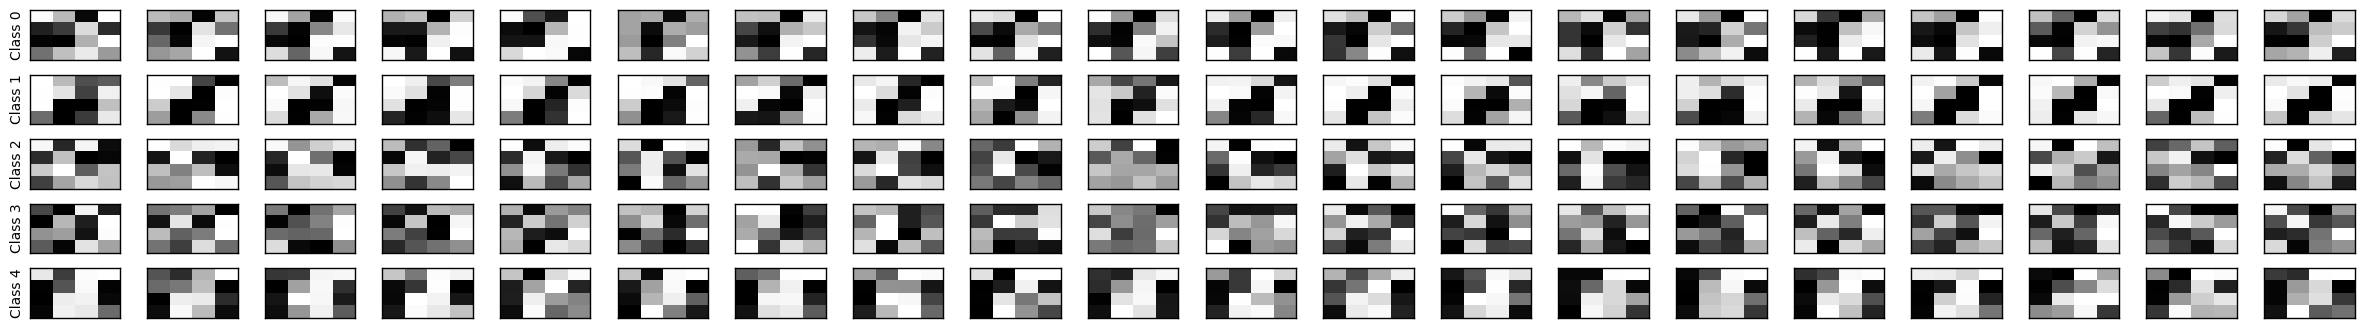

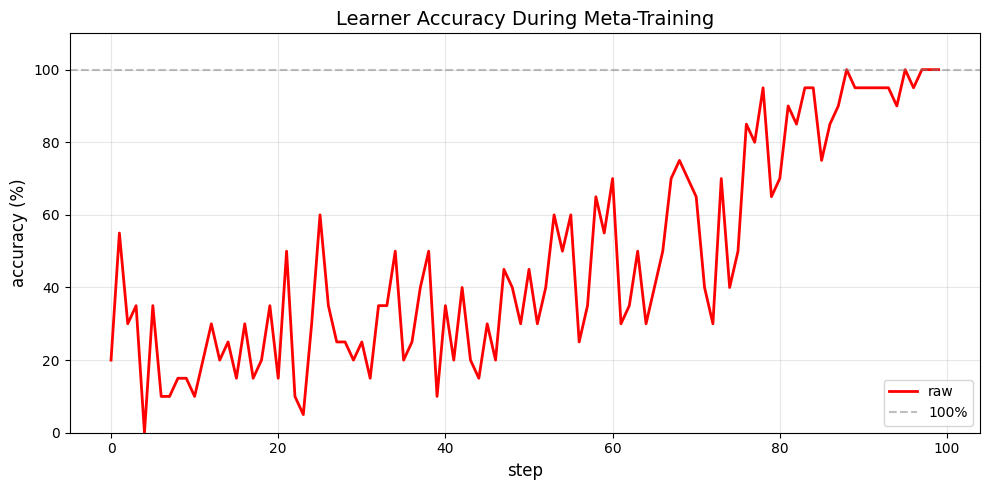

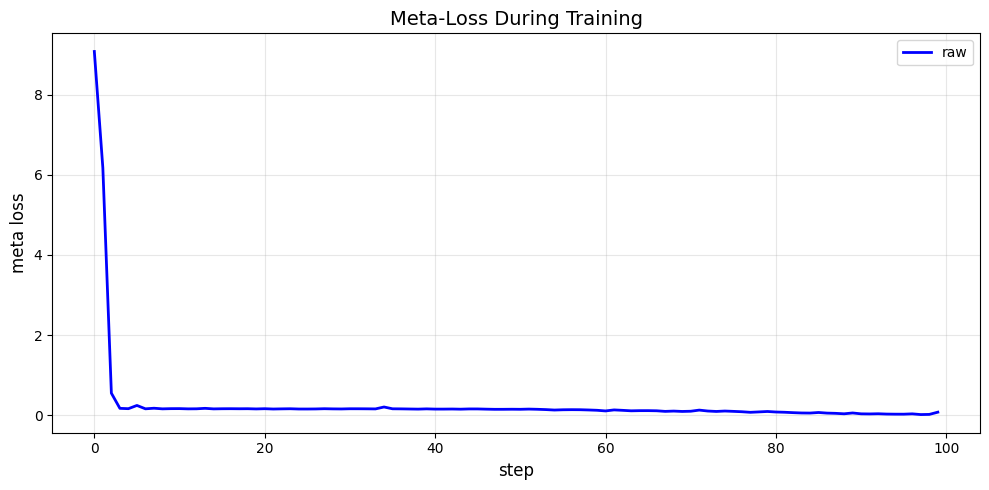

In [16]:
generator = Generator4x4(latent_dim=32, num_classes=5)

meta = MetaLearner(
    generator=generator,
    learner_class=CNN4x4,
    meta_loss_fn=mlf.meta_loss_mse,
    num_classes=5,
    n_per_class=20,
    latent_dim=32,
    regularization_fn=mlf.regularizer_svd_for_x,
    reg_parameter=100,
    meta_lr=0.01,
    inner_lr=0.1,
    inner_steps=100,
)

meta.train(steps=100, visualize_every=0)
meta.plot_accuracy(1)
meta.plot_meta_loss(1)
acc_mse_svd_reg = meta.get_accuracy_history()

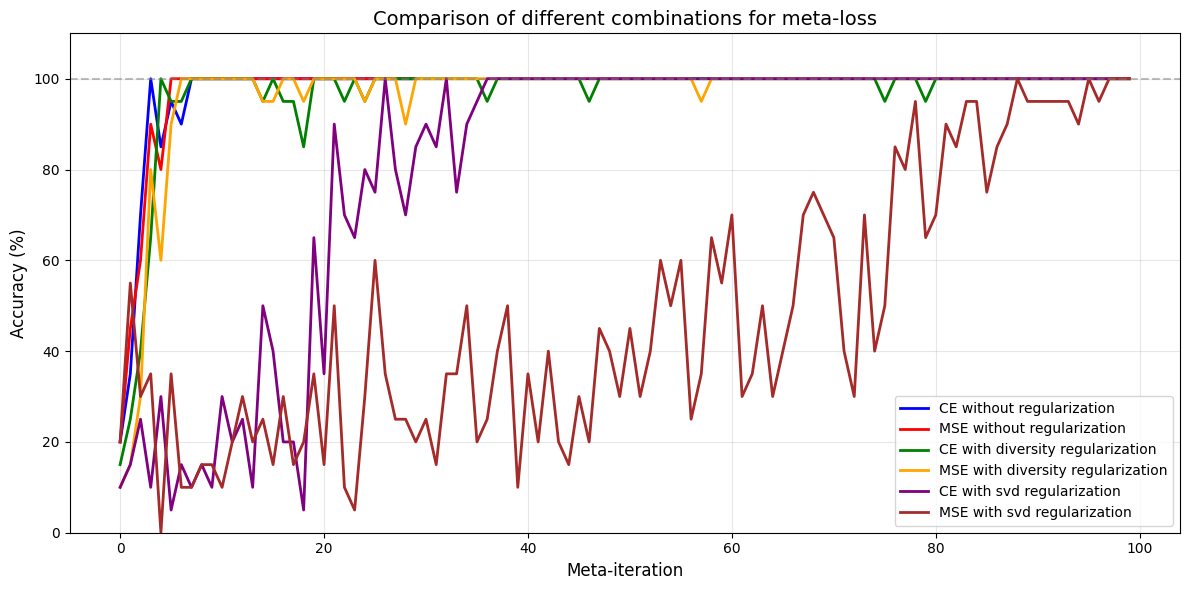

In [17]:
from Visualization import plot_accuracy_comparison

plot_accuracy_comparison(acc_ce_without_reg, acc_mse_without_reg, acc_ce_diversity_reg, acc_mse_diversity_reg, acc_ce_svd_reg, acc_mse_svd_reg,
                         labels=["CE without regularization", "MSE without regularization", "CE with diversity regularization", 
                                 "MSE with diversity regularization", "CE with svd regularization", "MSE with svd regularization"],
                                 title="Comparison of different combinations for meta-loss",
                                 smoothing_window=1)